# A06 - Delivery Overprovisioning

> **Dados legados.** Este notebook analisa campanhas congeladas, geradas
> com o modelo escalar de fidelidade (`ket_vector`) antes da revisão de
> realismo físico (`docs/physical_model.md`). Os números valem como
> registro do manuscrito V1, não para o modelo físico atual; os resultados
> que o manuscrito V2 usa estão em `results/realistic/`
> (`docs/realistic_results.md`).

## Objetivo
Analisar o fenomeno `delivered_pairs > reserved_memory_slots` com dados
reais e ja persistidos de todas as quatro campanhas (`C01`-`C04`): quao
comum e, sua relacao com duracao/memorias/estrategia, e por que
`reserved_memory_slots` nao e um teto de entrega no SeQUeNCe (ver
`docs/metrics.md`, `docs/intent_resource_semantics.md`). Este notebook
**nao roda nenhuma simulacao**.

## Conceitos
- `reserved_memory_slots` (Fase J2, antes chamado `requested_pairs`)
  dimensiona o **pool de memorias reservado** (`RSVPProtocol.schedule`),
  nao um limite de entregas: assim que uma memoria entrega um par, ela e
  resetada para `RAW` e pode gerar entrelacamento de novo, ate
  `reservation.end_time`.
- `min_delivered_pairs` e a meta de entrega em nivel de servico (separada
  do recurso reservado, Fase J2) - nas quatro campanhas piloto, ambas as
  intents curadas (diamond/three_node) declaram `min_delivered_pairs=10`,
  igual ao `reserved_memory_slots=10` que ja usavam, entao os valores
  numericos abaixo nao mudam em relacao a Fase H3 - so a semantica dos
  nomes ficou inequivoca.
- `excess_delivery_pairs = max(0, delivered_pairs - min_delivered_pairs)`;
  `delivery_ratio = delivered_pairs / min_delivered_pairs` (meta de
  servico); `deliveries_per_reserved_slot = delivered_pairs /
  reserved_memory_slots` (eficiencia de recurso) - todas calculadas uma
  vez, na persistencia do trial, nunca truncadas depois.


## Configuração


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from ibqn.experiments.persistence import read_trials_dataframe, trials_csv_path
from ibqn.experiments.export import save_figure, save_table

RESULTS_DIR = Path("../results")
FIGURES_DIR = RESULTS_DIR / "figures" / "article"
TABLES_DIR = RESULTS_DIR / "tables" / "article"
CAMPAIGNS = ["C01_routing_strategy", "C02_fidelity_throughput", "C03_assurance_outcomes", "C04_reconciliation_effectiveness"]

all_trials_df = pd.concat(
    [read_trials_dataframe(trials_csv_path(RESULTS_DIR, c)).assign(campaign_name=c) for c in CAMPAIGNS],
    ignore_index=True,
)
delivered_df = all_trials_df[all_trials_df["delivered_pairs"].notna()].copy()
delivered_df[[
    "campaign_name", "routing_strategy", "purification_policy", "duration_s",
    "reserved_memory_slots", "min_delivered_pairs", "delivered_pairs",
    "excess_delivery_pairs", "delivery_ratio", "deliveries_per_reserved_slot",
]]


,campaign_name,routing_strategy,purification_policy,duration_s,reserved_memory_slots,min_delivered_pairs,delivered_pairs,excess_delivery_pairs,delivery_ratio,deliveries_per_reserved_slot
0,C01_routing_strategy,shortest_hop_count,automatic,0.10,10,10,4.0,0.0,0.4,0.4
1,C01_routing_strategy,shortest_hop_count,automatic,0.10,10,10,5.0,0.0,0.5,0.5
2,C01_routing_strategy,shortest_hop_count,automatic,0.10,10,10,4.0,0.0,0.4,0.4
3,C01_routing_strategy,least_loss,automatic,0.10,10,10,444.0,434.0,44.4,44.4
4,C01_routing_strategy,least_loss,automatic,0.10,10,10,450.0,440.0,45.0,45.0
5,C01_routing_strategy,least_loss,automatic,0.10,10,10,445.0,435.0,44.5,44.5
6,C01_routing_strategy,highest_fidelity,automatic,0.10,10,10,4.0,0.0,0.4,0.4
7,C01_routing_strategy,highest_fidelity,automatic,0.10,10,10,5.0,0.0,0.5,0.5
8,C01_routing_strategy,highest_fidelity,automatic,0.10,10,10,4.0,0.0,0.4,0.4
9,C02_fidelity_throughput,shortest_hop_count,disabled,0.05,10,10,237.0,227.0,23.7,23.7


## Execução


In [2]:
print(f"n = {len(delivered_df)} trials with delivery evidence")
print(f"trials with delivered_pairs > min_delivered_pairs: {(delivered_df['excess_delivery_pairs'] > 0).sum()} / {len(delivered_df)}")
print(f"delivery_ratio: min={delivered_df['delivery_ratio'].min():.2f}, median={delivered_df['delivery_ratio'].median():.2f}, max={delivered_df['delivery_ratio'].max():.2f}")
print(f"deliveries_per_reserved_slot: min={delivered_df['deliveries_per_reserved_slot'].min():.2f}, median={delivered_df['deliveries_per_reserved_slot'].median():.2f}, max={delivered_df['deliveries_per_reserved_slot'].max():.2f}")


n = 27 trials with delivery evidence
trials with delivered_pairs > min_delivered_pairs: 16 / 27
delivery_ratio: min=0.10, median=5.80, max=45.70
deliveries_per_reserved_slot: min=0.10, median=5.80, max=45.70


## Resultados


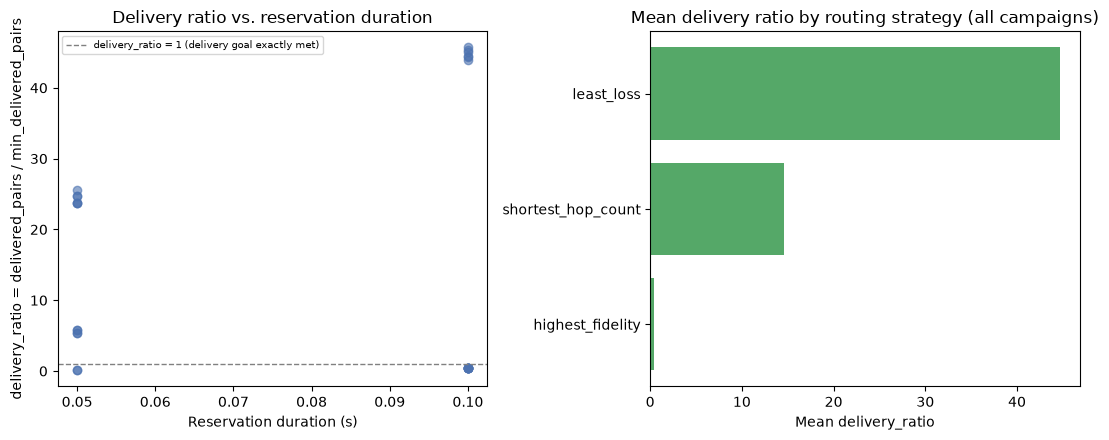

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(delivered_df["duration_s"], delivered_df["delivery_ratio"], alpha=0.6, c="#4C72B0")
axes[0].set_xlabel("Reservation duration (s)")
axes[0].set_ylabel("delivery_ratio = delivered_pairs / min_delivered_pairs")
axes[0].axhline(1.0, color="gray", linestyle="--", linewidth=1, label="delivery_ratio = 1 (delivery goal exactly met)")
axes[0].set_title("Delivery ratio vs. reservation duration")
axes[0].legend(fontsize=7)

by_strategy = delivered_df.groupby("routing_strategy")["delivery_ratio"].mean().sort_values()
axes[1].barh(by_strategy.index.astype(str), by_strategy.values, color="#55A868")
axes[1].set_xlabel("Mean delivery_ratio")
axes[1].set_title("Mean delivery ratio by routing strategy (all campaigns)")

fig.tight_layout()
save_figure(fig, "A06_delivery_overprovisioning", directory=FIGURES_DIR)
plt.show()


In [4]:
by_purification = delivered_df[delivered_df["purification_policy"].notna()].groupby("purification_policy")[["delivery_ratio", "deliveries_per_reserved_slot"]].agg(["count", "mean", "median"])
save_table(by_purification.reset_index(), "A06_delivery_ratio_by_purification", directory=TABLES_DIR)
by_purification


delivery_ratio                 \
                             count    mean median   
purification_policy                                 
automatic                       25  15.724    5.4   
disabled                         2  24.200   24.2   

                    deliveries_per_reserved_slot                 
                                           count    mean median  
purification_policy                                              
automatic                                     25  15.724    5.4  
disabled                                       2  24.200   24.2

In [5]:
extreme_case = delivered_df.loc[delivered_df["delivery_ratio"].idxmax()]
print(f"Largest overprovisioning observed: campaign={extreme_case['campaign_name']}, strategy={extreme_case['routing_strategy']}, "
      f"min_delivered_pairs={extreme_case['min_delivered_pairs']:.0f}, delivered={extreme_case['delivered_pairs']:.0f}, "
      f"delivery_ratio={extreme_case['delivery_ratio']:.1f}x")


Largest overprovisioning observed: campaign=C04_reconciliation_effectiveness, strategy=shortest_hop_count, min_delivered_pairs=10, delivered=457, delivery_ratio=45.7x


In [6]:
assert (delivered_df["delivered_pairs"] >= 0).all()
assert (delivered_df["excess_delivery_pairs"] == (delivered_df["delivered_pairs"] - delivered_df["min_delivered_pairs"]).clip(lower=0)).all()
assert (delivered_df["deliveries_per_reserved_slot"] == delivered_df["delivered_pairs"] / delivered_df["reserved_memory_slots"]).all()
assert (delivered_df["delivery_ratio"] > 1).any(), "overprovisioning must actually occur somewhere in this dataset"
print(f"Confirmed: {(delivered_df['delivery_ratio'] > 1).sum()} / {len(delivered_df)} trials delivered more pairs than their min_delivered_pairs goal.")


Confirmed: 16 / 27 trials delivered more pairs than their min_delivered_pairs goal.


## Interpretação
A maioria dos trials com uma rota de baixa perda (`least_loss` no diamante,
ou o cenário `three_node` sem purificação) entrega dezenas a centenas de
vezes mais pares que a meta declarada, porque a janela de reserva
(`duration_s`) é o fator que realmente limita a entrega, não
`reserved_memory_slots`/`min_delivered_pairs`. Purificação reduz
sistematicamente o `delivery_ratio` médio (cada par purificado consome
mais recursos brutos por par final entregue - notebook 17 da Fase H2),
mas não o elimina. Isso confirma quantitativamente, com dados de
campanha, o que já era conhecido qualitativamente desde o notebook 01 da
Fase H1. Nas quatro campanhas piloto, `delivery_ratio` e
`deliveries_per_reserved_slot` coincidem numericamente (ambas as intents
curadas declaram `min_delivered_pairs == reserved_memory_slots == 10`) -
os dois passam a divergir apenas quando esses dois valores diferem (ver
`docs/intent_resource_semantics.md`).

## Limitações
- As quatro campanhas não foram desenhadas para variar sistematicamente
  `duration_s` sozinho (mantendo tudo mais fixo) - a relação
  duração-vs-overprovisioning aqui é observacional, não um sweep
  controlado dedicado a essa pergunta.
- Nenhuma das campanhas piloto varia `reserved_memory_slots` e
  `min_delivered_pairs` independentemente ainda - as duas métricas
  derivadas coincidem numericamente aqui por coincidência de design, não
  por necessidade.
- `delivery_ratio`/`deliveries_per_reserved_slot` não são penalizados nem
  recompensados por nenhuma condição de sucesso desta arquitetura - são
  puramente informativos.

## Conclusão
`reserved_memory_slots` confirmado, com dados reais de campanha, como um
dimensionamento de pool de memórias - não um teto de entrega; o quanto se
excede em relação à meta de serviço (`min_delivered_pairs`) depende
principalmente da janela de tempo e da rota/estratégia, não de nenhum
limite deliberado do requisito declarado.
